In [1]:
import os
import numpy as np
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2



In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debeshjha1/kvasirseg")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'kvasirseg' dataset.
Path to dataset files: /kaggle/input/kvasirseg


In [3]:
os.listdir(path)

['val.txt', 'README.md', 'train.txt', 'Kvasir-SEG']

In [4]:
ROOT_DIR = os.path.join(path,'Kvasir-SEG' )

In [5]:
ROOT_DIR2 = os.path.join(ROOT_DIR,'Kvasir-SEG' )
dir_list = sorted(os.listdir(ROOT_DIR2))
dir_list

['1911.07069.pdf', 'annotated_images', 'bbox', 'images', 'masks']

In [6]:
image_dir = os.path.join(ROOT_DIR2, dir_list[3])
mask_dir = os.path.join(ROOT_DIR2, dir_list[4])

print(mask_dir, image_dir)

/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks /kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/images


In [7]:
mask_list = sorted(os.listdir(image_dir))
image_list = sorted(os.listdir(mask_dir))

In [8]:
mask_list[1:10], image_list[1:10]

(['cju0qoxqj9q6s0835b43399p4.jpg',
  'cju0qx73cjw570799j4n5cjze.jpg',
  'cju0roawvklrq0799vmjorwfv.jpg',
  'cju0rx1idathl0835detmsp84.jpg',
  'cju0s2a9ekvms080138tjjpxr.jpg',
  'cju0s690hkp960855tjuaqvv0.jpg',
  'cju0sr5ghl0nd08789uzf1raf.jpg',
  'cju0sxqiclckk08551ycbwhno.jpg',
  'cju0t4oil7vzk099370nun5h9.jpg'],
 ['cju0qoxqj9q6s0835b43399p4.jpg',
  'cju0qx73cjw570799j4n5cjze.jpg',
  'cju0roawvklrq0799vmjorwfv.jpg',
  'cju0rx1idathl0835detmsp84.jpg',
  'cju0s2a9ekvms080138tjjpxr.jpg',
  'cju0s690hkp960855tjuaqvv0.jpg',
  'cju0sr5ghl0nd08789uzf1raf.jpg',
  'cju0sxqiclckk08551ycbwhno.jpg',
  'cju0t4oil7vzk099370nun5h9.jpg'])

In [9]:
for i in range(0, 100):
  if mask_list[i] != image_list[i]: print('images and masks are not same')

In [10]:
class KvasirSegDataset(Dataset):
    def __init__(self, image_root, mask_root, image_list, mask_list, transformer=None):
        self.image_root = image_root
        self.mask_root = mask_root
        self.image_list = image_list
        self.mask_list = mask_list
        self.transformer = transformer

        assert len(self.image_list) == len(self.mask_list), \
            "Image list and mask list must be same length"

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):

        img_path = os.path.join(self.image_root, self.image_list[idx])
        mask_path = os.path.join(self.mask_root, self.mask_list[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.transformer:
            augmented = self.transformer(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # ---------------- CRITICAL FIX ----------------

        # image → CHW
        if isinstance(image, np.ndarray):
            image = image.transpose(2, 0, 1)

        # mask → ALWAYS enforce 1 channel
        if isinstance(mask, np.ndarray):
            if mask.ndim == 2:
                mask = np.expand_dims(mask, axis=0)

        # if Albumentations returned torch tensor
        if torch.is_tensor(mask):
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)

        if torch.is_tensor(image):
            image = image.float()
        else:
            image = torch.tensor(image, dtype=torch.float32)

        if torch.is_tensor(mask):
            mask = mask.float()
        else:
            mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [11]:
train_transform = A.Compose([

    A.Resize(224, 224),

    # Geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=30, p=0.5),

    # Elastic deformation (VERY useful for medical images)
    A.ElasticTransform(
        alpha=1,
        sigma=50,
        alpha_affine=50,
        p=0.2
    ),

    # Scale + shift (simulates zooming)
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=0,
        p=0.5
    ),

    # Photometric augmentations (colonoscopy lighting varies a lot)
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(p=0.3),
    A.GaussianBlur(p=0.2),
    A.GaussNoise(p=0.2),

    # Normalize image
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0
    ),

    # Convert to tensor
    ToTensorV2()
])

/tmp/ipykernel_2978/4196021012.py:11: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [12]:
val_transform = A.Compose([
    A.Resize(224, 224),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0
    ),

    ToTensorV2()
])

In [13]:
train_images, val_images, train_masks, val_masks = train_test_split(
    image_list,
    mask_list,
    test_size=0.2,
    random_state=42
)

In [14]:
train_dataset = KvasirSegDataset(
    image_root=image_dir,
    mask_root=mask_dir,
    image_list=train_images,
    mask_list=train_masks,
    transformer=train_transform
)

val_dataset = KvasirSegDataset(
    image_root=image_dir,
    mask_root=mask_dir,
    image_list=val_images,
    mask_list=val_masks,
    transformer=val_transform
)

In [15]:
train_loader = DataLoader(
    train_dataset,
    batch_size= 64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size= 64,
    shuffle=False
)

In [16]:
images, masks = next(iter(train_loader))
print(images.shape)  # (B, 3, H, W)
print(masks.shape)   # (B, 1, H, W)

torch.Size([64, 3, 224, 224])
torch.Size([64, 1, 224, 224])


In [17]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )
        return 1 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, preds, targets):
        return self.bce(preds, targets) + self.dice(preds, targets)

In [18]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [19]:
class SwinUNet(nn.Module):
    def __init__(
        self,
        backbone="swin_tiny_patch4_window7_224",
        pretrained=True,
        num_classes=1
    ):
        super().__init__()

        # ---------------- SWIN ENCODER ----------------
        self.encoder = timm.create_model(
            backbone,
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        ch = self.encoder.feature_info.channels()
        c1, c2, c3, c4 = ch

        # ---------------- DECODER ----------------
        self.up3 = nn.ConvTranspose2d(c4, 256, 2, 2)
        self.dec3 = ConvBlock(256 + c3, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = ConvBlock(128 + c2, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = ConvBlock(64 + c1, 64)

        self.up0 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec0 = ConvBlock(32, 32)

        self.seg_head = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):

        # ---------------- ENCODER ----------------
        feats = self.encoder(x)
        e1, e2, e3, e4 = feats
        e1 = e1.permute(0, 3, 1, 2).contiguous()
        e2 = e2.permute(0, 3, 1, 2).contiguous()
        e3 = e3.permute(0, 3, 1, 2).contiguous()
        e4 = e4.permute(0, 3, 1, 2).contiguous()

        # ---------------- DECODER ----------------
        d3 = self.up3(e4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        d0 = self.up0(d1)
        d0 = self.dec0(d0)

        out = self.seg_head(d0)

        out = F.interpolate(
            out,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        return out

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SwinUNet().to(device)

criterion_seg = BCEDiceLoss()


optimizer = torch.optim.AdamW(
    [
        # ---------------- SWIN ENCODER (pretrained backbone) ----------------
        {
            "params": model.encoder.parameters(),
            "lr": 3e-5
        },

        # ---------------- DECODER ----------------
        {
            "params": (
                list(model.up3.parameters()) +
                list(model.dec3.parameters()) +

                list(model.up2.parameters()) +
                list(model.dec2.parameters()) +

                list(model.up1.parameters()) +
                list(model.dec1.parameters()) +

                list(model.up0.parameters()) +
                list(model.dec0.parameters()) +

                list(model.seg_head.parameters())
            ),
            "lr": 2e-4
        }
    ],
    weight_decay=1e-4
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [21]:
def dice_score(preds, targets, smooth=1):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()

    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (
        preds.sum() + targets.sum() + smooth
    )

In [22]:
best_loss = float("inf")
patience = 7
counter = 0
epochs = 200

save_dir = "./checkpoints"
os.makedirs(save_dir, exist_ok=True)

# ---------------- OPTIMIZER ----------------
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ---------------- LR SCHEDULER ----------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# ---------------- HISTORY (like tf.keras) ----------------
history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "lr": []
}

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        seg_out = model(images)
        loss = criterion_seg(seg_out, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= max(len(train_loader), 1)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            seg_out = model(images)

            loss = criterion_seg(seg_out, masks)

            val_loss += loss.item()
            val_dice += dice_score(seg_out, masks).item()

    val_loss /= max(len(val_loader), 1)
    val_dice /= max(len(val_loader), 1)

    # ---------------- LR SCHEDULER ----------------
    scheduler.step(val_loss)

    # current learning rate
    current_lr = optimizer.param_groups[0]["lr"]

    # ---------------- STORE HISTORY ----------------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["lr"].append(current_lr)

    # ---------------- LOGGING ----------------
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # ---------------- SAVE BEST MODEL ----------------
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), f"{save_dir}/best_model.pth")
        print(f"Best model saved at epoch {epoch+1}")

    else:
        counter += 1

    # ---------------- EARLY STOPPING ----------------
    if counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

    # ---------------- SAVE LAST MODEL ----------------
    torch.save(model.state_dict(), f"{save_dir}/last_model.pth")

Epoch [1/200] | Train Loss: 1.2613 | Val Loss: 1.2835 | Val Dice: 0.7763 | LR: 0.000030
Best model saved at epoch 1
Epoch [2/200] | Train Loss: 1.0180 | Val Loss: 1.0175 | Val Dice: 0.7819 | LR: 0.000030
Best model saved at epoch 2
Epoch [3/200] | Train Loss: 0.9396 | Val Loss: 0.9390 | Val Dice: 0.7553 | LR: 0.000030
Best model saved at epoch 3
Epoch [4/200] | Train Loss: 0.8934 | Val Loss: 0.7948 | Val Dice: 0.8361 | LR: 0.000030
Best model saved at epoch 4
Epoch [5/200] | Train Loss: 0.8618 | Val Loss: 0.7852 | Val Dice: 0.8447 | LR: 0.000030
Best model saved at epoch 5
Epoch [6/200] | Train Loss: 0.8409 | Val Loss: 0.7777 | Val Dice: 0.8469 | LR: 0.000030
Best model saved at epoch 6
Epoch [7/200] | Train Loss: 0.8156 | Val Loss: 0.7540 | Val Dice: 0.8580 | LR: 0.000030
Best model saved at epoch 7
Epoch [8/200] | Train Loss: 0.7932 | Val Loss: 0.7483 | Val Dice: 0.8388 | LR: 0.000030
Best model saved at epoch 8
Epoch [9/200] | Train Loss: 0.7712 | Val Loss: 0.7215 | Val Dice: 0.8526

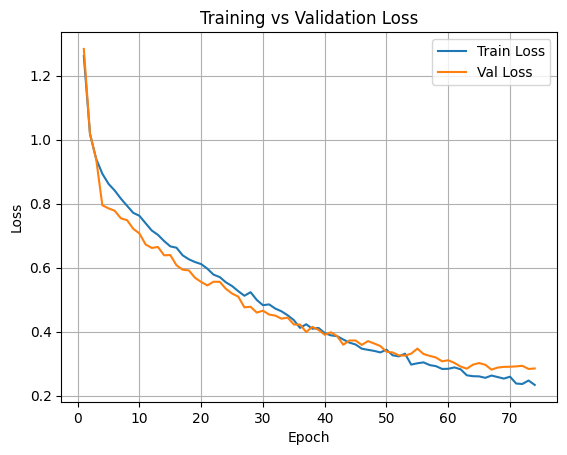

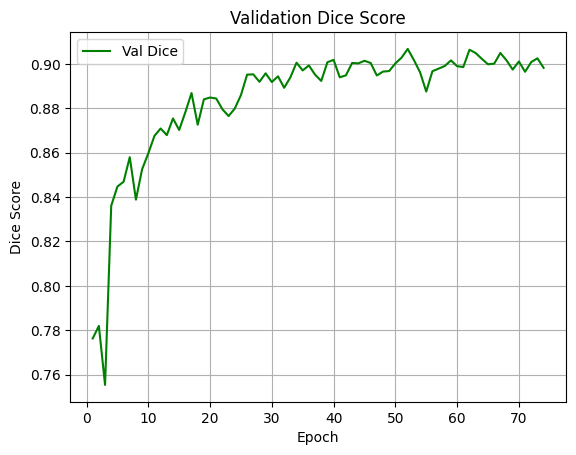

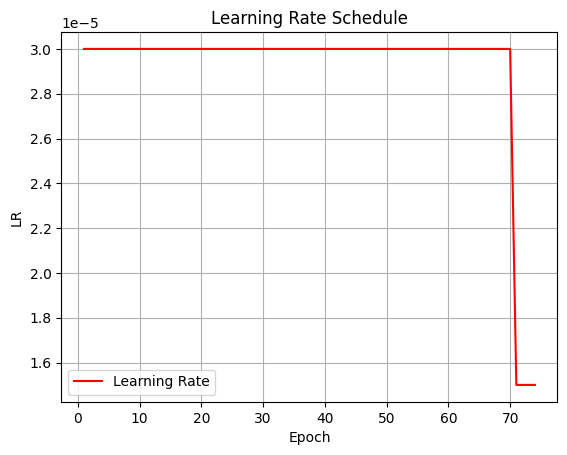

In [23]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure()
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(epochs_range, history["val_dice"], label="Val Dice", color="green")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dice Score")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(epochs_range, history["lr"], label="Learning Rate", color="red")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("Learning Rate Schedule")
plt.legend()
plt.grid()
plt.show()

In [25]:
model = SwinUNet( pretrained=False)
model = model.to(device)

checkpoint_path = "./checkpoints/best_model.pth"

model.load_state_dict(torch.load(checkpoint_path, map_location=device))

<All keys matched successfully>

In [26]:
def dice_score(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    target = target.float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))

    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()

In [27]:
def iou_score(pred, target, eps=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    target = target.float()

    intersection = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred * target).sum(dim=(1,2,3))

    iou = (intersection + eps) / (union + eps)
    return iou.mean()

In [28]:
def pixel_accuracy(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()
    correct = (pred == target).float().sum()
    total = torch.numel(target)
    return correct / total

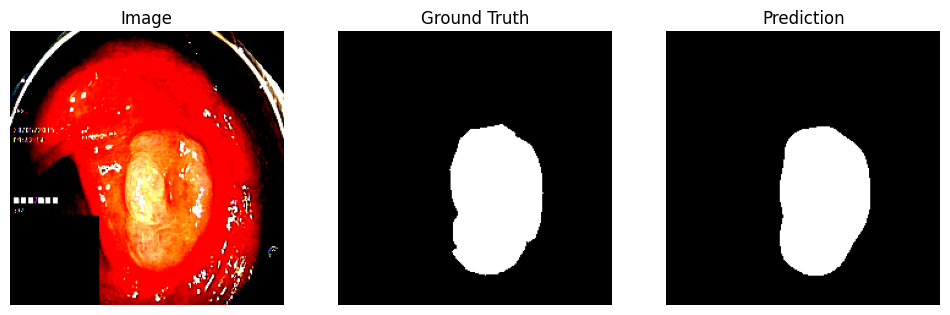

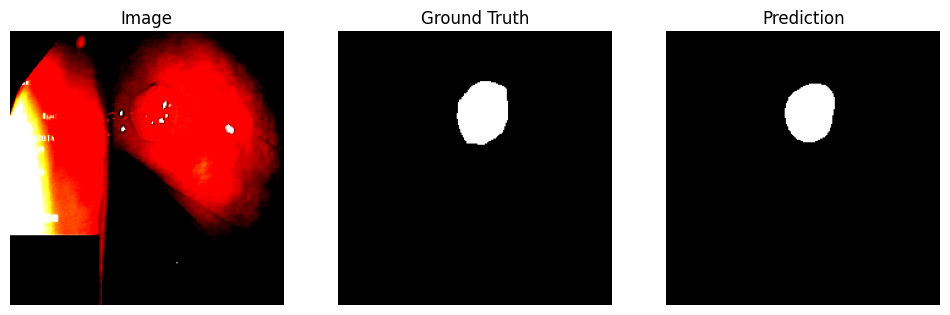

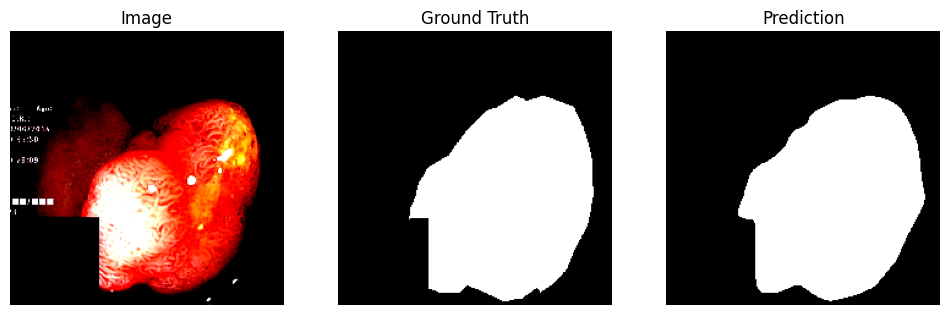

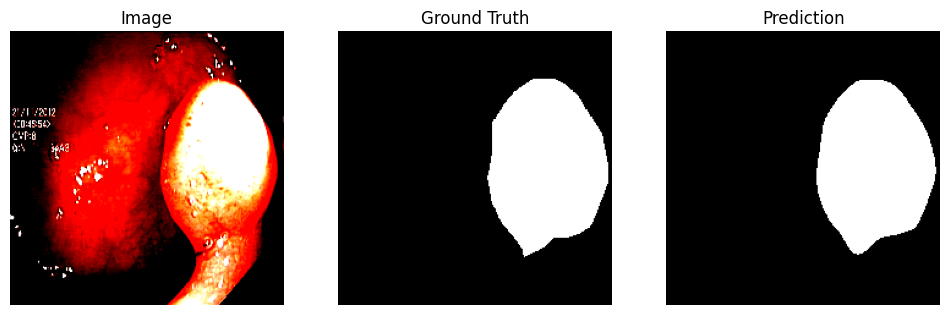

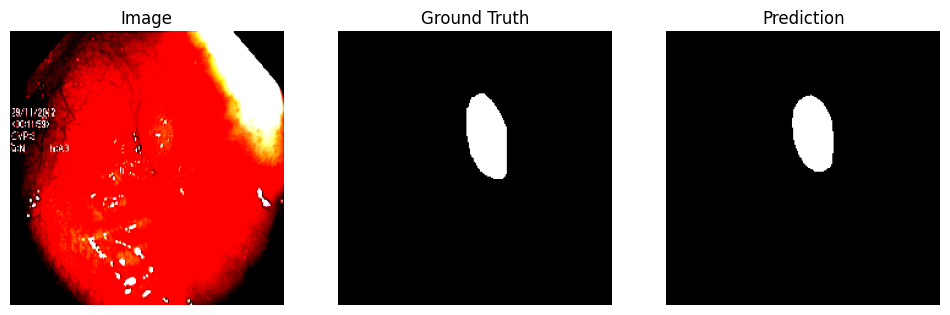

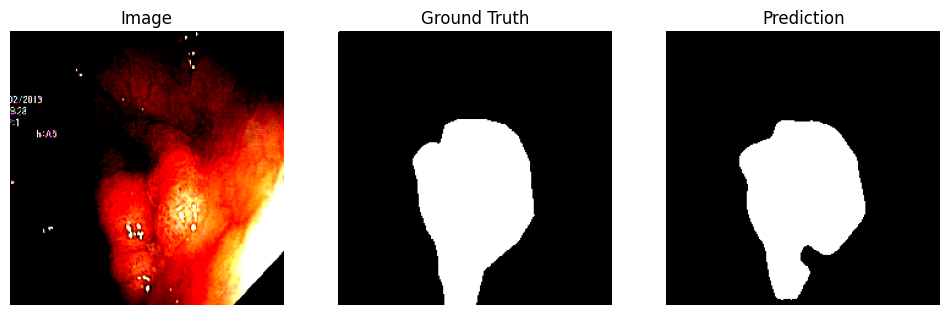

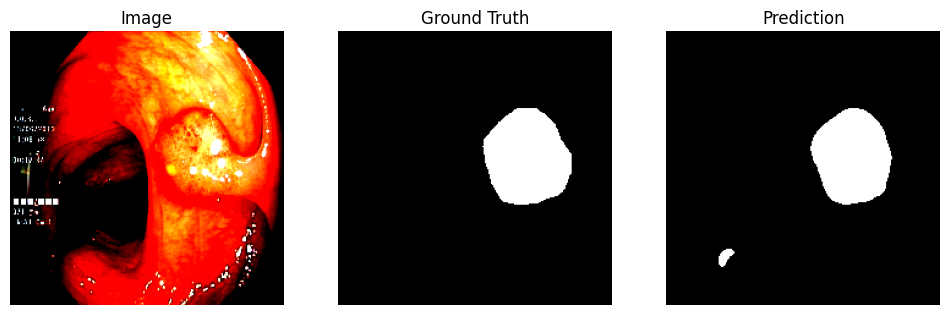

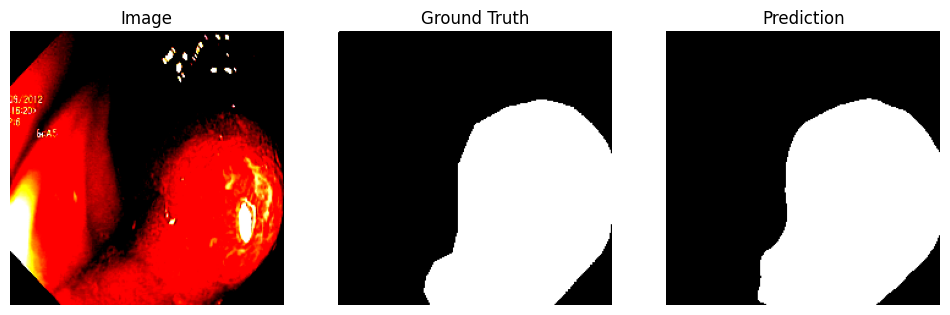

In [29]:
import seaborn as sns
model.eval()

dice_list = []
iou_list = []
acc_list = []

with torch.no_grad():
    for i, (images, masks) in enumerate(val_loader):

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        # ---------------- METRICS ----------------
        dice = dice_score(outputs, masks)
        iou = iou_score(outputs, masks)
        acc = pixel_accuracy(outputs, masks)

        dice_list.append(dice.item())
        iou_list.append(iou.item())
        acc_list.append(acc.item())

        # ---------------- VISUALIZATION (first batch only) ----------------
        if i % 2 == 0:
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()

            images = images.cpu().numpy()
            masks = masks.cpu().numpy()
            preds = preds.cpu().numpy()

            for j in range(min(4, images.shape[0])):

                img = images[j].transpose(1,2,0)
                mask = masks[j][0]
                pred = preds[j][0]

                plt.figure(figsize=(12,4))

                plt.subplot(1,3,1)
                plt.title("Image")
                plt.imshow(img)
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.title("Ground Truth")
                plt.imshow(mask, cmap="gray")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.title("Prediction")
                plt.imshow(pred, cmap="gray")
                plt.axis("off")

                plt.show()

In [30]:
print("===== VALIDATION RESULTS =====")
print(f"Dice Score  : {np.mean(dice_list):.4f}")
print(f"IoU Score   : {np.mean(iou_list):.4f}")
print(f"Pixel Acc   : {np.mean(acc_list):.4f}")

===== VALIDATION RESULTS =====
Dice Score  : 0.8906
IoU Score   : 0.8309
Pixel Acc   : 0.9689


In [31]:
def get_confusion_matrix(pred, target):
    """
    pred, target: tensors of shape (B, 1, H, W)
    """

    pred = (torch.sigmoid(pred) > 0.5).float()
    target = target.float()

    TP = (pred * target).sum().item()
    TN = ((1 - pred) * (1 - target)).sum().item()
    FP = (pred * (1 - target)).sum().item()
    FN = ((1 - pred) * target).sum().item()

    return np.array([[TP, FP],
                     [FN, TN]])

In [32]:
model.eval()

cm_total = np.zeros((2, 2))

with torch.no_grad():
    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        cm = get_confusion_matrix(outputs, masks)
        cm_total += cm

In [33]:
cm_norm = cm_total / cm_total.sum()

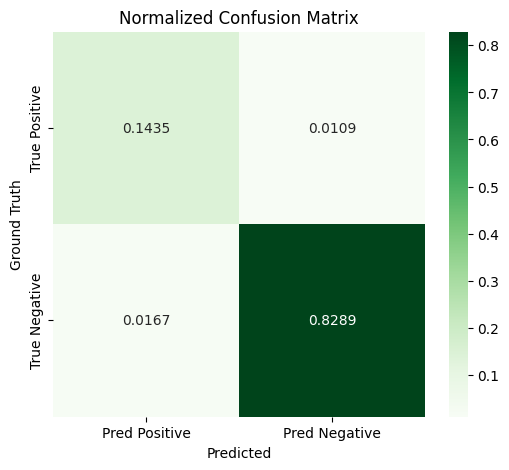

In [34]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".4f",
    cmap="Greens",
    xticklabels=["Pred Positive", "Pred Negative"],
    yticklabels=["True Positive", "True Negative"]
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.show()